# MODIS Vegetation Analysis - Production Notebook

**Enhanced version with:**
- Organized output structure
- Administrative level analysis
- Comprehensive reporting
- Error handling and logging

---

## 1. Setup and Configuration

In [1]:
# Import the production analyzer
from modis_vegetation_analyzer import MODISVegetationAnalyzer
from report_utils import ReportGenerator, generate_markdown_report
from helper_utils import save_uploaded_file, create_upload_widget
import json
from pathlib import Path

print("✅ Imports successful")


✅ Imports successful


In [2]:
# Define configuration (customize as needed)
config = {
    "ee_project": "ee-my-ndungu",
    "output_base_dir": "modis_outputs",
    "year": 2024,
    "indices": ["NDVI", "EVI", "VCI"],
    "composite_methods": ["mean"],
    "scale": 250
}

# Save config
with open('notebook_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Configuration saved")
print(json.dumps(config, indent=2))

✅ Configuration saved
{
  "ee_project": "ee-my-ndungu",
  "output_base_dir": "modis_outputs",
  "year": 2024,
  "indices": [
    "NDVI",
    "EVI",
    "VCI"
  ],
  "composite_methods": [
    "mean"
  ],
  "scale": 250
}


## 2. Initialize Analyzer

In [3]:
# Initialize the analyzer with config
analyzer = MODISVegetationAnalyzer(config_path='notebook_config.json')

# Initialize Earth Engine
analyzer.initialize_ee()

print("✅ Analyzer initialized")

2026-02-16 16:06:10,844 - MODISAnalyzer - INFO - ✅ Earth Engine initialized with project: ee-my-ndungu


✅ Analyzer initialized


## 3. Load Area of Interest (AOI)

In [4]:
# Upload AOI file using widget
from IPython.display import display

upload_widget = create_upload_widget()
display(upload_widget)
print("⏳ Please upload your AOI file...")

FileUpload(value=(), accept='.zip,.geojson,.json,.shp,.dbf,.shx,.prj', description='📁 Upload AOI')

⏳ Please upload your AOI file...


In [5]:
# Process uploaded file
if upload_widget.value:
    try:
        # Save uploaded file using helper function
        filename = save_uploaded_file(upload_widget)
        print(f"✅ File saved: {filename}")
        
        # Load AOI
        analyzer.load_aoi(filename)
        
        print(f"✅ AOI loaded successfully!")
        print(f"   Features: {len(analyzer.aoi_gdf)}")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("   Please check your file and try again.")
else:
    print("⚠️  No file uploaded. Please upload a file in the cell above.")

2026-02-16 16:06:24,631 - MODISAnalyzer - INFO - 📂 Loading AOI from: Kiambu.geojson


✅ File saved: Kiambu.geojson


2026-02-16 16:06:24,859 - MODISAnalyzer - INFO - ✅ AOI loaded successfully with 1 features


✅ AOI loaded successfully!
   Features: 1


## 4. Visualize AOI (Optional)

In [6]:
import geemap

# Create interactive map
Map = geemap.Map()
Map.centerObject(analyzer.aoi, zoom=8)
Map.addLayer(analyzer.aoi, {}, 'AOI Boundary')
Map

Map(center=[-1.0663333046950283, 36.82274849394715], controls=(WidgetControl(options=['position', 'transparent…

## 5. Run Complete Analysis

This will:
1. Create organized output structure
2. Fetch MODIS data
3. Calculate vegetation indices
4. Generate monthly composites
5. Calculate statistics
6. Analyze by administrative levels
7. Create visualizations

In [7]:
# Create output structure
analyzer.create_output_structure()
print(f"📁 Output directory: {analyzer.output_dir}")

2026-02-16 16:06:37,552 - MODISAnalyzer - INFO - 📁 Output structure created at: modis_outputs/analysis_20260216_160637


📁 Output directory: modis_outputs/analysis_20260216_160637


In [8]:
# Fetch MODIS data
year = config['year']
start_date = f"{year}-01-01"
end_date = f"{year}-12-31"

print(f"📡 Fetching MODIS data for {year}...")
collection = analyzer.get_modis_data(start_date, end_date)

# Calculate VCI
print("🧮 Calculating VCI...")
historical_start = f"{year-10}-01-01"
historical_end = f"{year-1}-12-31"
collection = analyzer.calculate_vci(collection, historical_start, historical_end)

print("✅ Data prepared")

2026-02-16 16:06:40,211 - MODISAnalyzer - INFO - 📡 Fetching MODIS data from 2024-01-01 to 2024-12-31


📡 Fetching MODIS data for 2024...


2026-02-16 16:06:41,257 - MODISAnalyzer - INFO -    Found 23 MODIS images
2026-02-16 16:06:41,272 - MODISAnalyzer - INFO -    ✅ Applied scaling factor (×0.0001) to NDVI and EVI
2026-02-16 16:06:41,276 - MODISAnalyzer - INFO - 🧮 Calculating VCI using historical baseline
2026-02-16 16:06:41,279 - MODISAnalyzer - INFO -    Historical period: 2014-01-01 to 2023-12-31


🧮 Calculating VCI...


2026-02-16 16:06:42,670 - MODISAnalyzer - INFO -    Found 230 historical images
2026-02-16 16:06:42,689 - MODISAnalyzer - INFO -    ✅ Historical baseline calculated
2026-02-16 16:06:42,945 - MODISAnalyzer - INFO -    ✅ VCI calculated and added to collection


✅ Data prepared


In [9]:
# Create monthly composites
print("🎨 Creating monthly composites...")
composites = analyzer.create_monthly_composites(collection, year)

print("🖼️  Exporting composite images...")
analyzer.export_composite_images(composites)

print("✅ Composites complete")

2026-02-16 16:06:52,605 - MODISAnalyzer - INFO - ✅ Created 36 monthly composites
2026-02-16 16:06:52,608 - MODISAnalyzer - INFO - 🖼️  Exporting composite visualizations...


🎨 Creating monthly composites...
🖼️  Exporting composite images...


2026-02-16 16:11:26,850 - MODISAnalyzer - INFO - ✅ Composite export complete


✅ Composites complete


In [10]:
# Calculate statistics
print("📊 Calculating monthly statistics...")
stats_df = analyzer.calculate_statistics(collection, year)

print("\n📈 Monthly Statistics Summary:")
display(stats_df[['Month', 'NDVI_mean', 'EVI_mean', 'VCI_mean']])

print("✅ Statistics calculated")

2026-02-16 16:11:40,602 - MODISAnalyzer - INFO - 📊 Calculating monthly statistics...


📊 Calculating monthly statistics...


2026-02-16 16:12:59,007 - MODISAnalyzer - INFO - ✅ Statistics saved to modis_outputs/analysis_20260216_160637/statistics/monthly_summary_2024.csv
2026-02-16 16:12:59,009 - MODISAnalyzer - INFO - 
📈 Statistics Summary:
2026-02-16 16:12:59,014 - MODISAnalyzer - INFO -    NDVI: mean=0.6626, min=0.5031, max=0.7239
2026-02-16 16:12:59,018 - MODISAnalyzer - INFO -    EVI: mean=0.3923, min=0.2843, max=0.4423
2026-02-16 16:12:59,021 - MODISAnalyzer - INFO -    VCI: mean=72.9828, min=53.9174, max=80.6396



📈 Monthly Statistics Summary:


,Month,NDVI_mean,EVI_mean,VCI_mean
0,1,0.656564,0.420062,72.401118
1,2,0.669944,0.385427,73.673113
2,3,0.660806,0.358555,72.494883
3,4,0.713514,0.415166,79.255958
4,5,0.715412,0.442299,79.594928
5,6,0.695287,0.433836,77.191432
6,7,0.675028,0.404372,74.665433
7,8,0.503074,0.284250,53.917424
8,9,0.604437,0.344382,65.354957
9,10,0.642948,0.339860,70.081473


✅ Statistics calculated


In [11]:
# Create trend plots
print("📈 Creating trend plots...")
analyzer.create_trend_plots(stats_df, year)

print("✅ Trends plotted")

2026-02-16 16:13:21,879 - MODISAnalyzer - INFO - 📈 Creating trend plots...


📈 Creating trend plots...


2026-02-16 16:13:28,419 - MODISAnalyzer - INFO - ✅ Trend plots created


✅ Trends plotted


In [12]:
# Generate metadata
analyzer.generate_metadata()

print("✅ Analysis complete!")
print(f"\n📁 All results saved to: {analyzer.output_dir}")

2026-02-16 16:13:32,170 - MODISAnalyzer - INFO - 📄 Metadata saved to modis_outputs/analysis_20260216_160637/metadata/analysis_metadata.json


✅ Analysis complete!

📁 All results saved to: modis_outputs/analysis_20260216_160637


## 6. View Results


NDVI Trend:


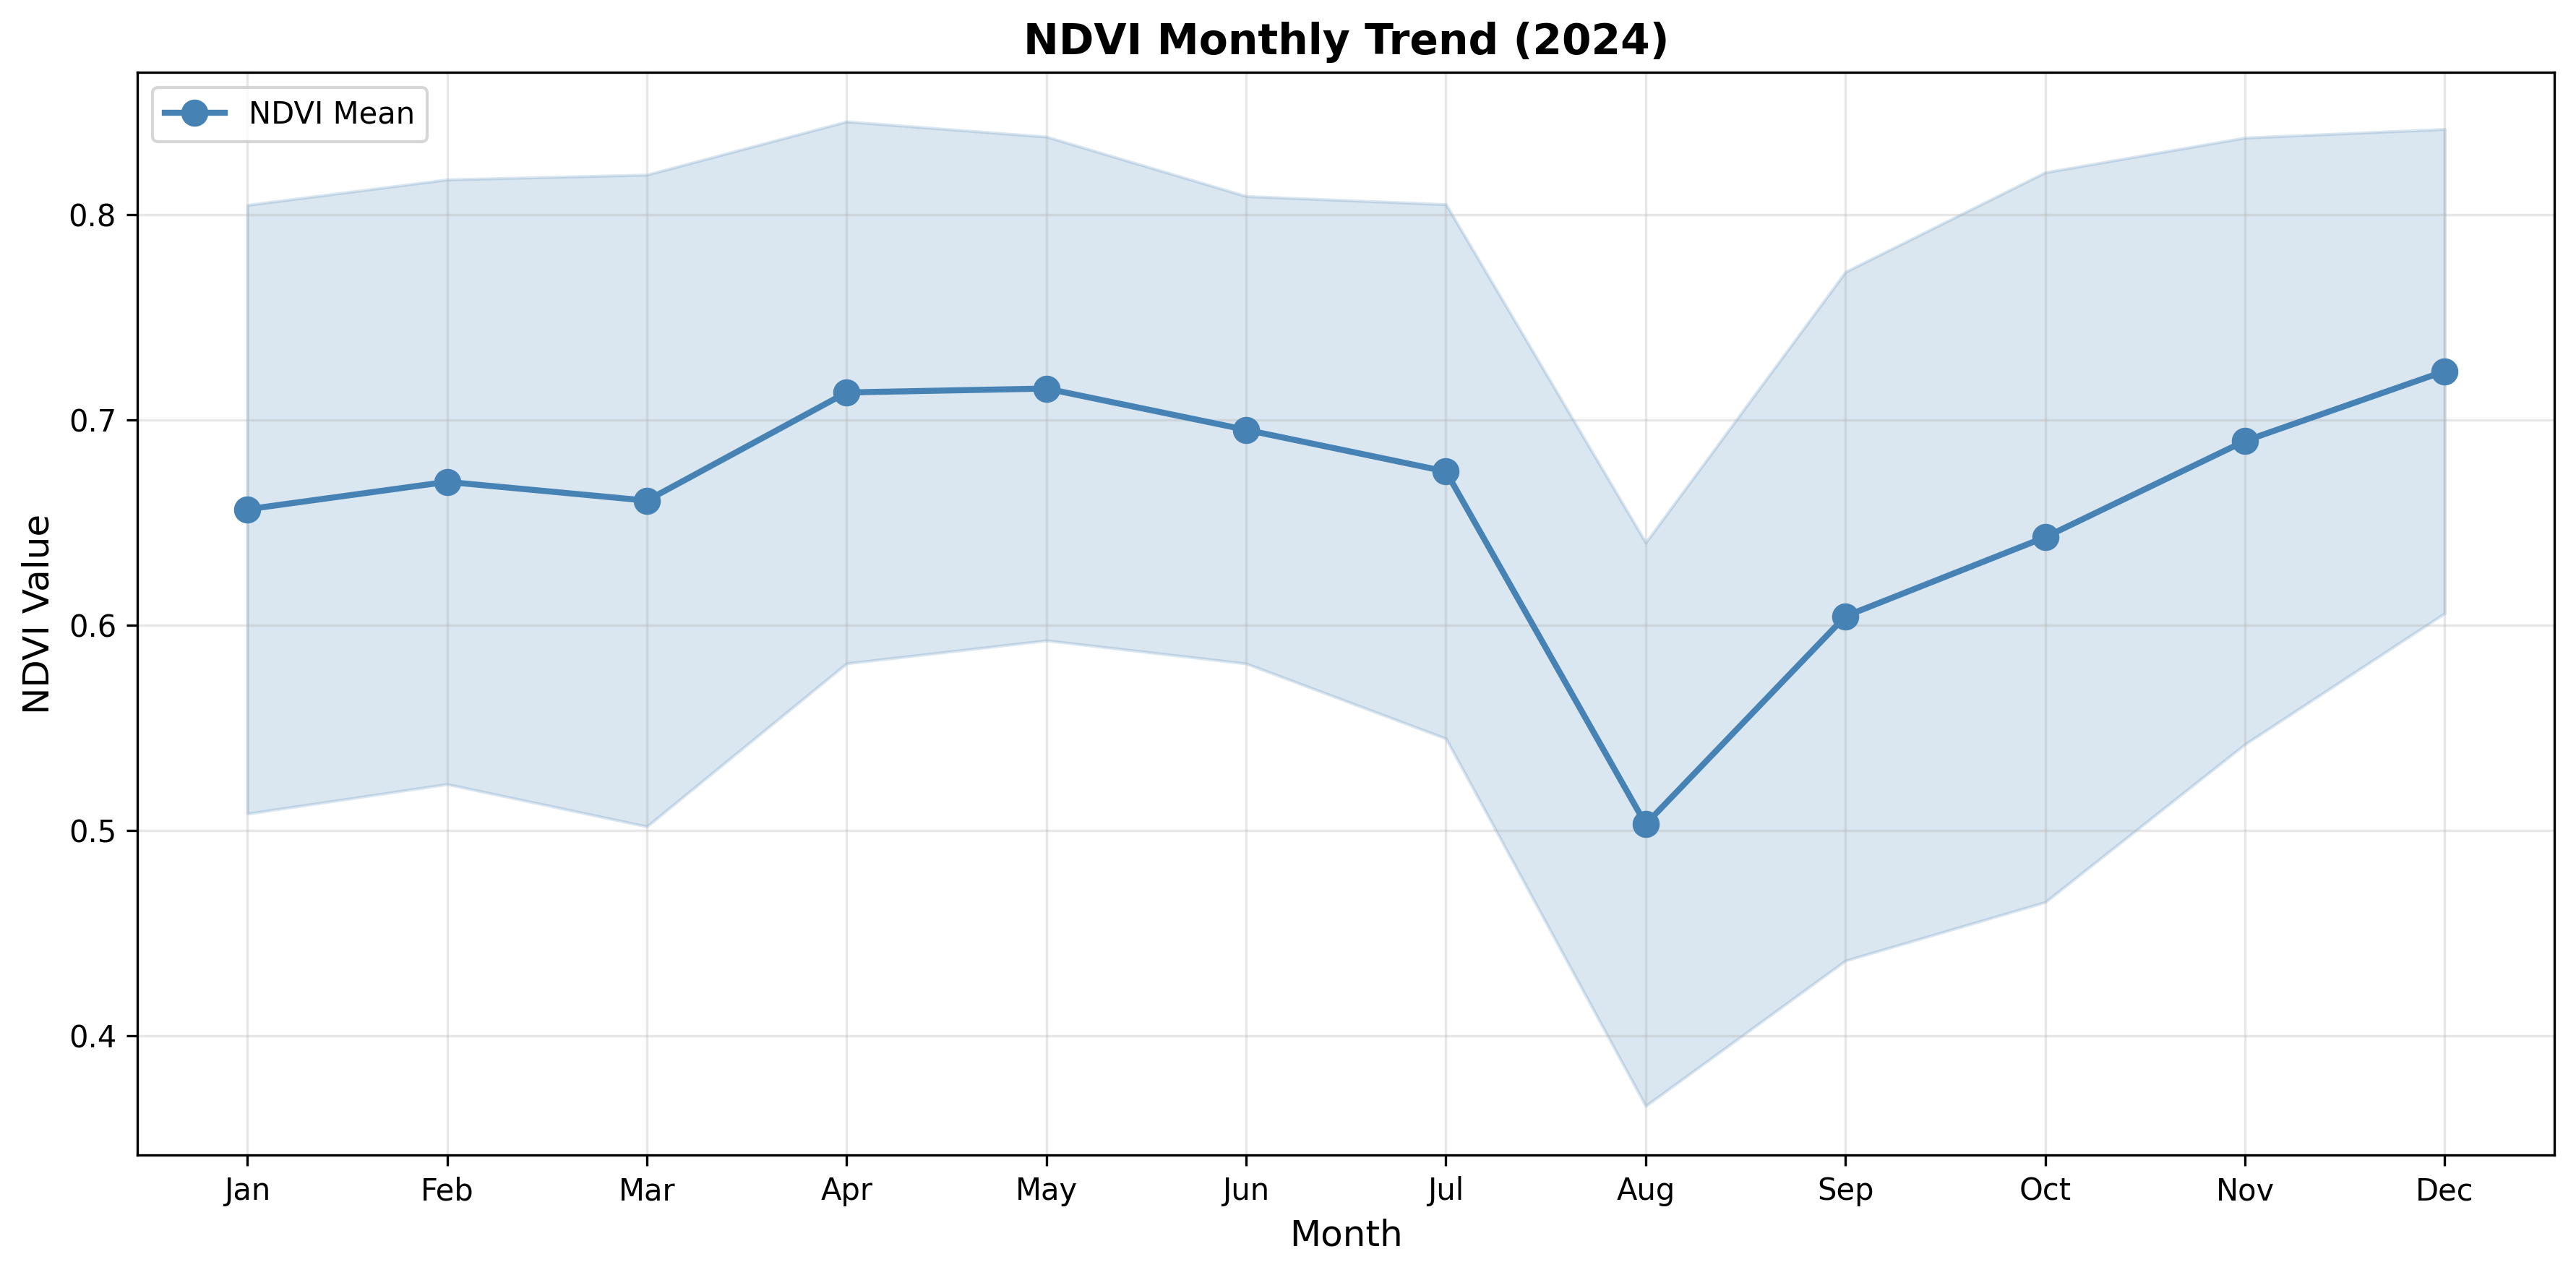


EVI Trend:


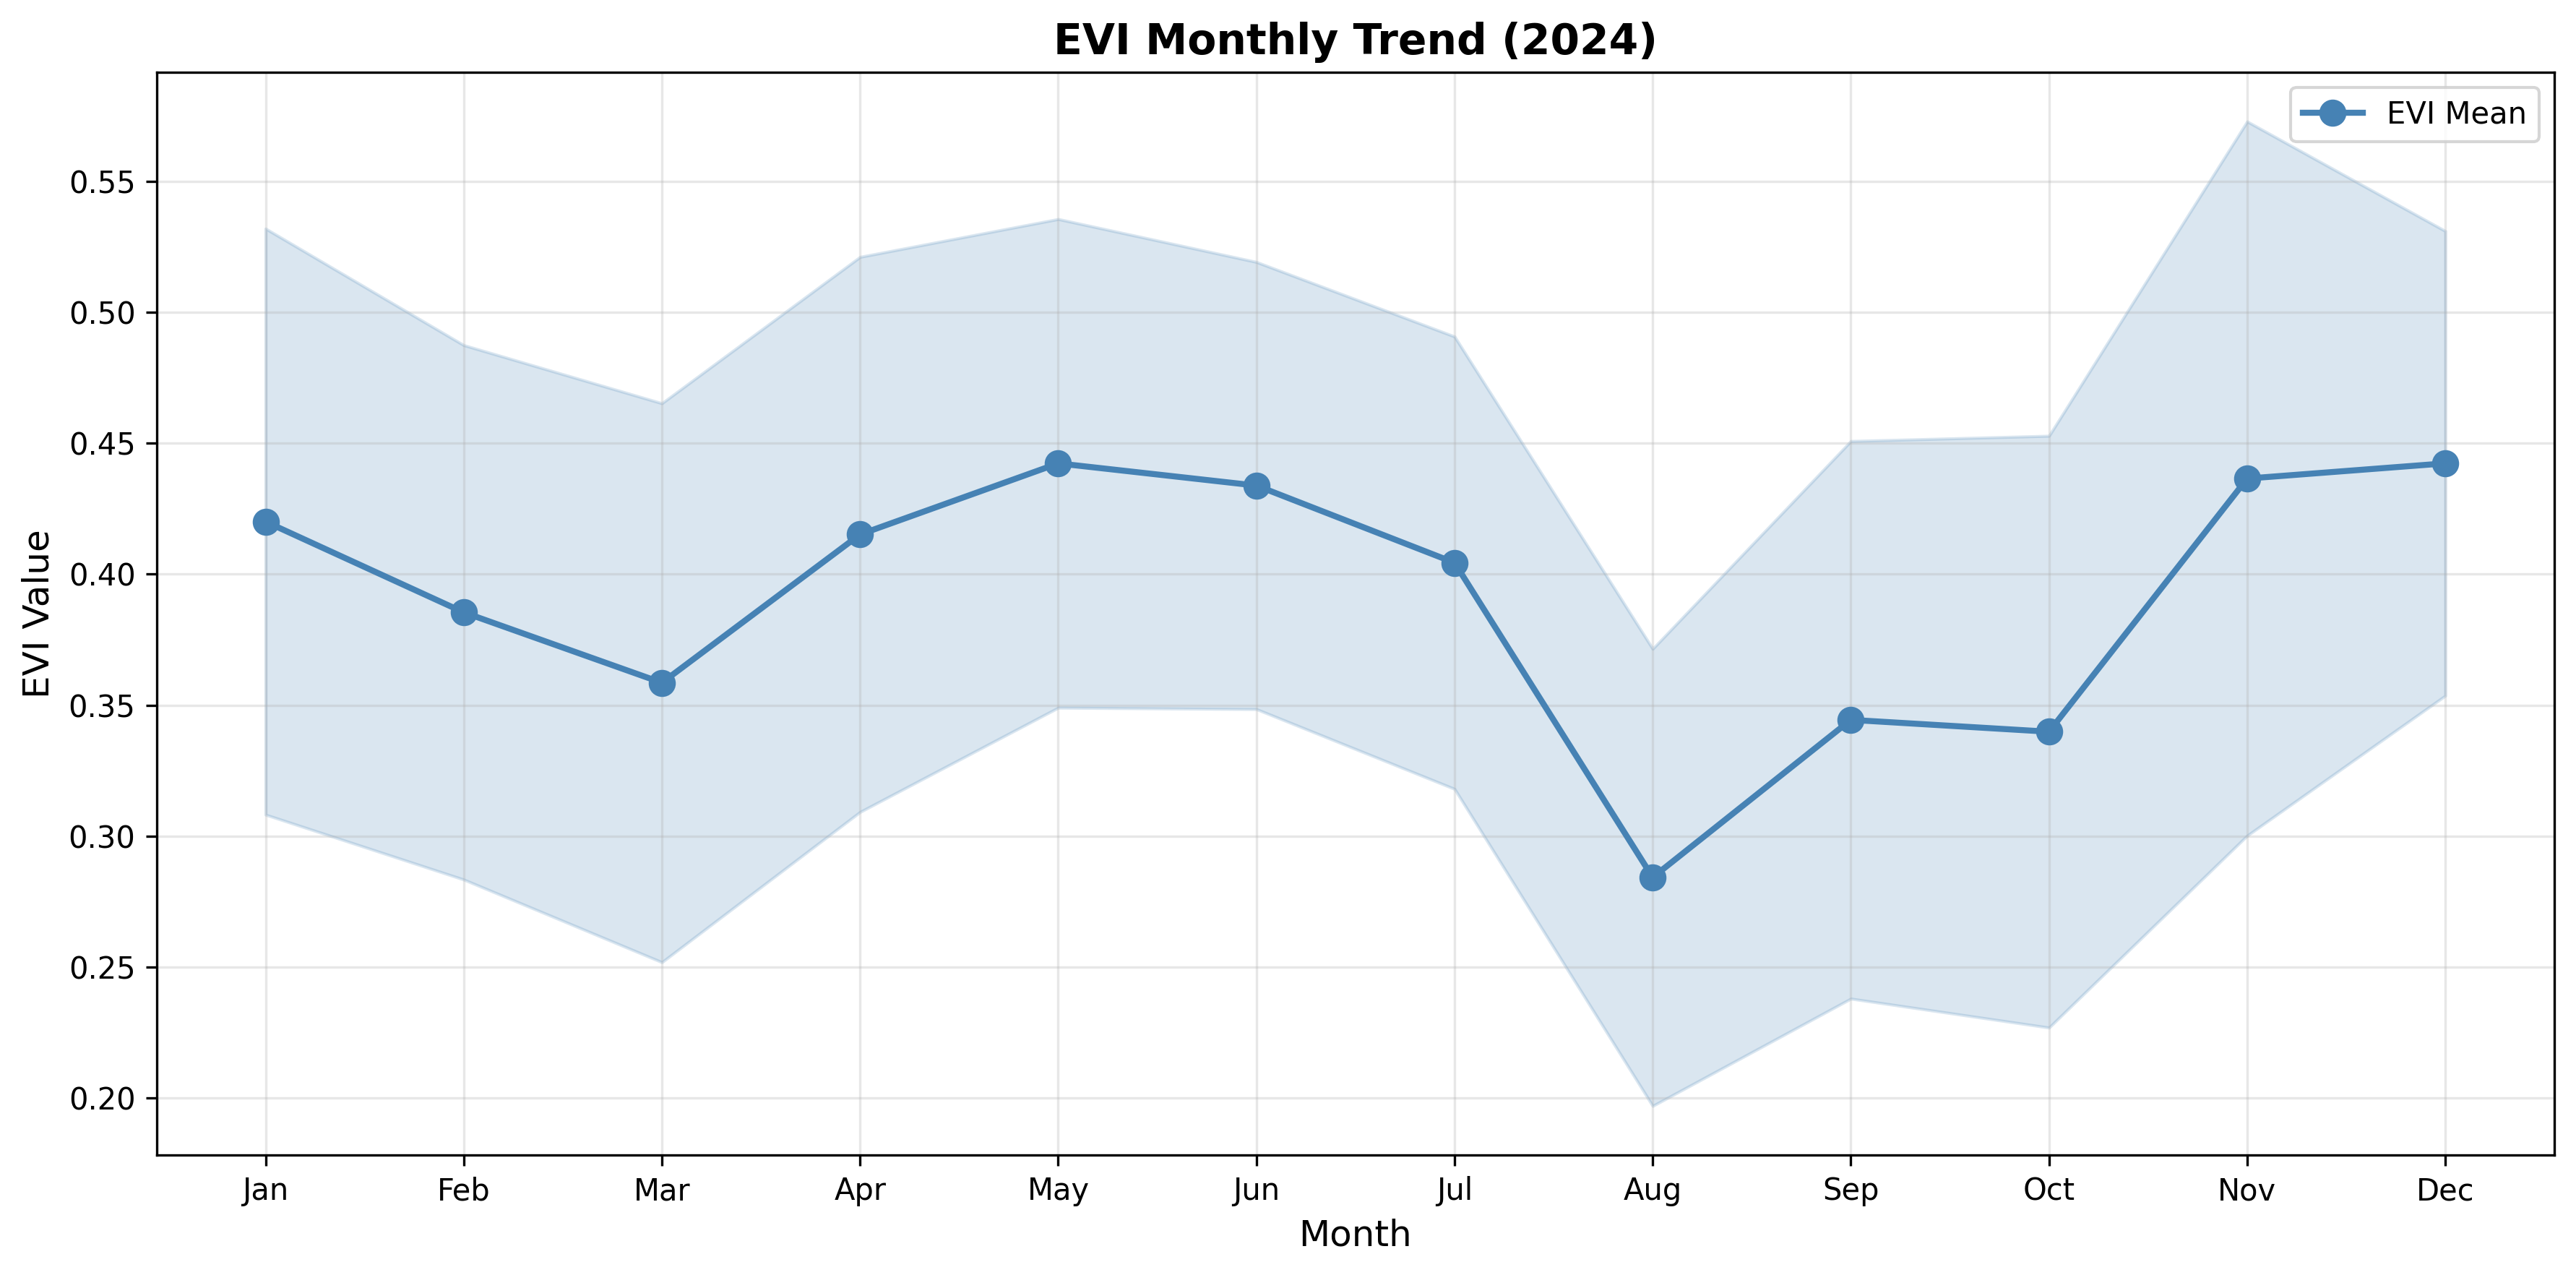


VCI Trend:


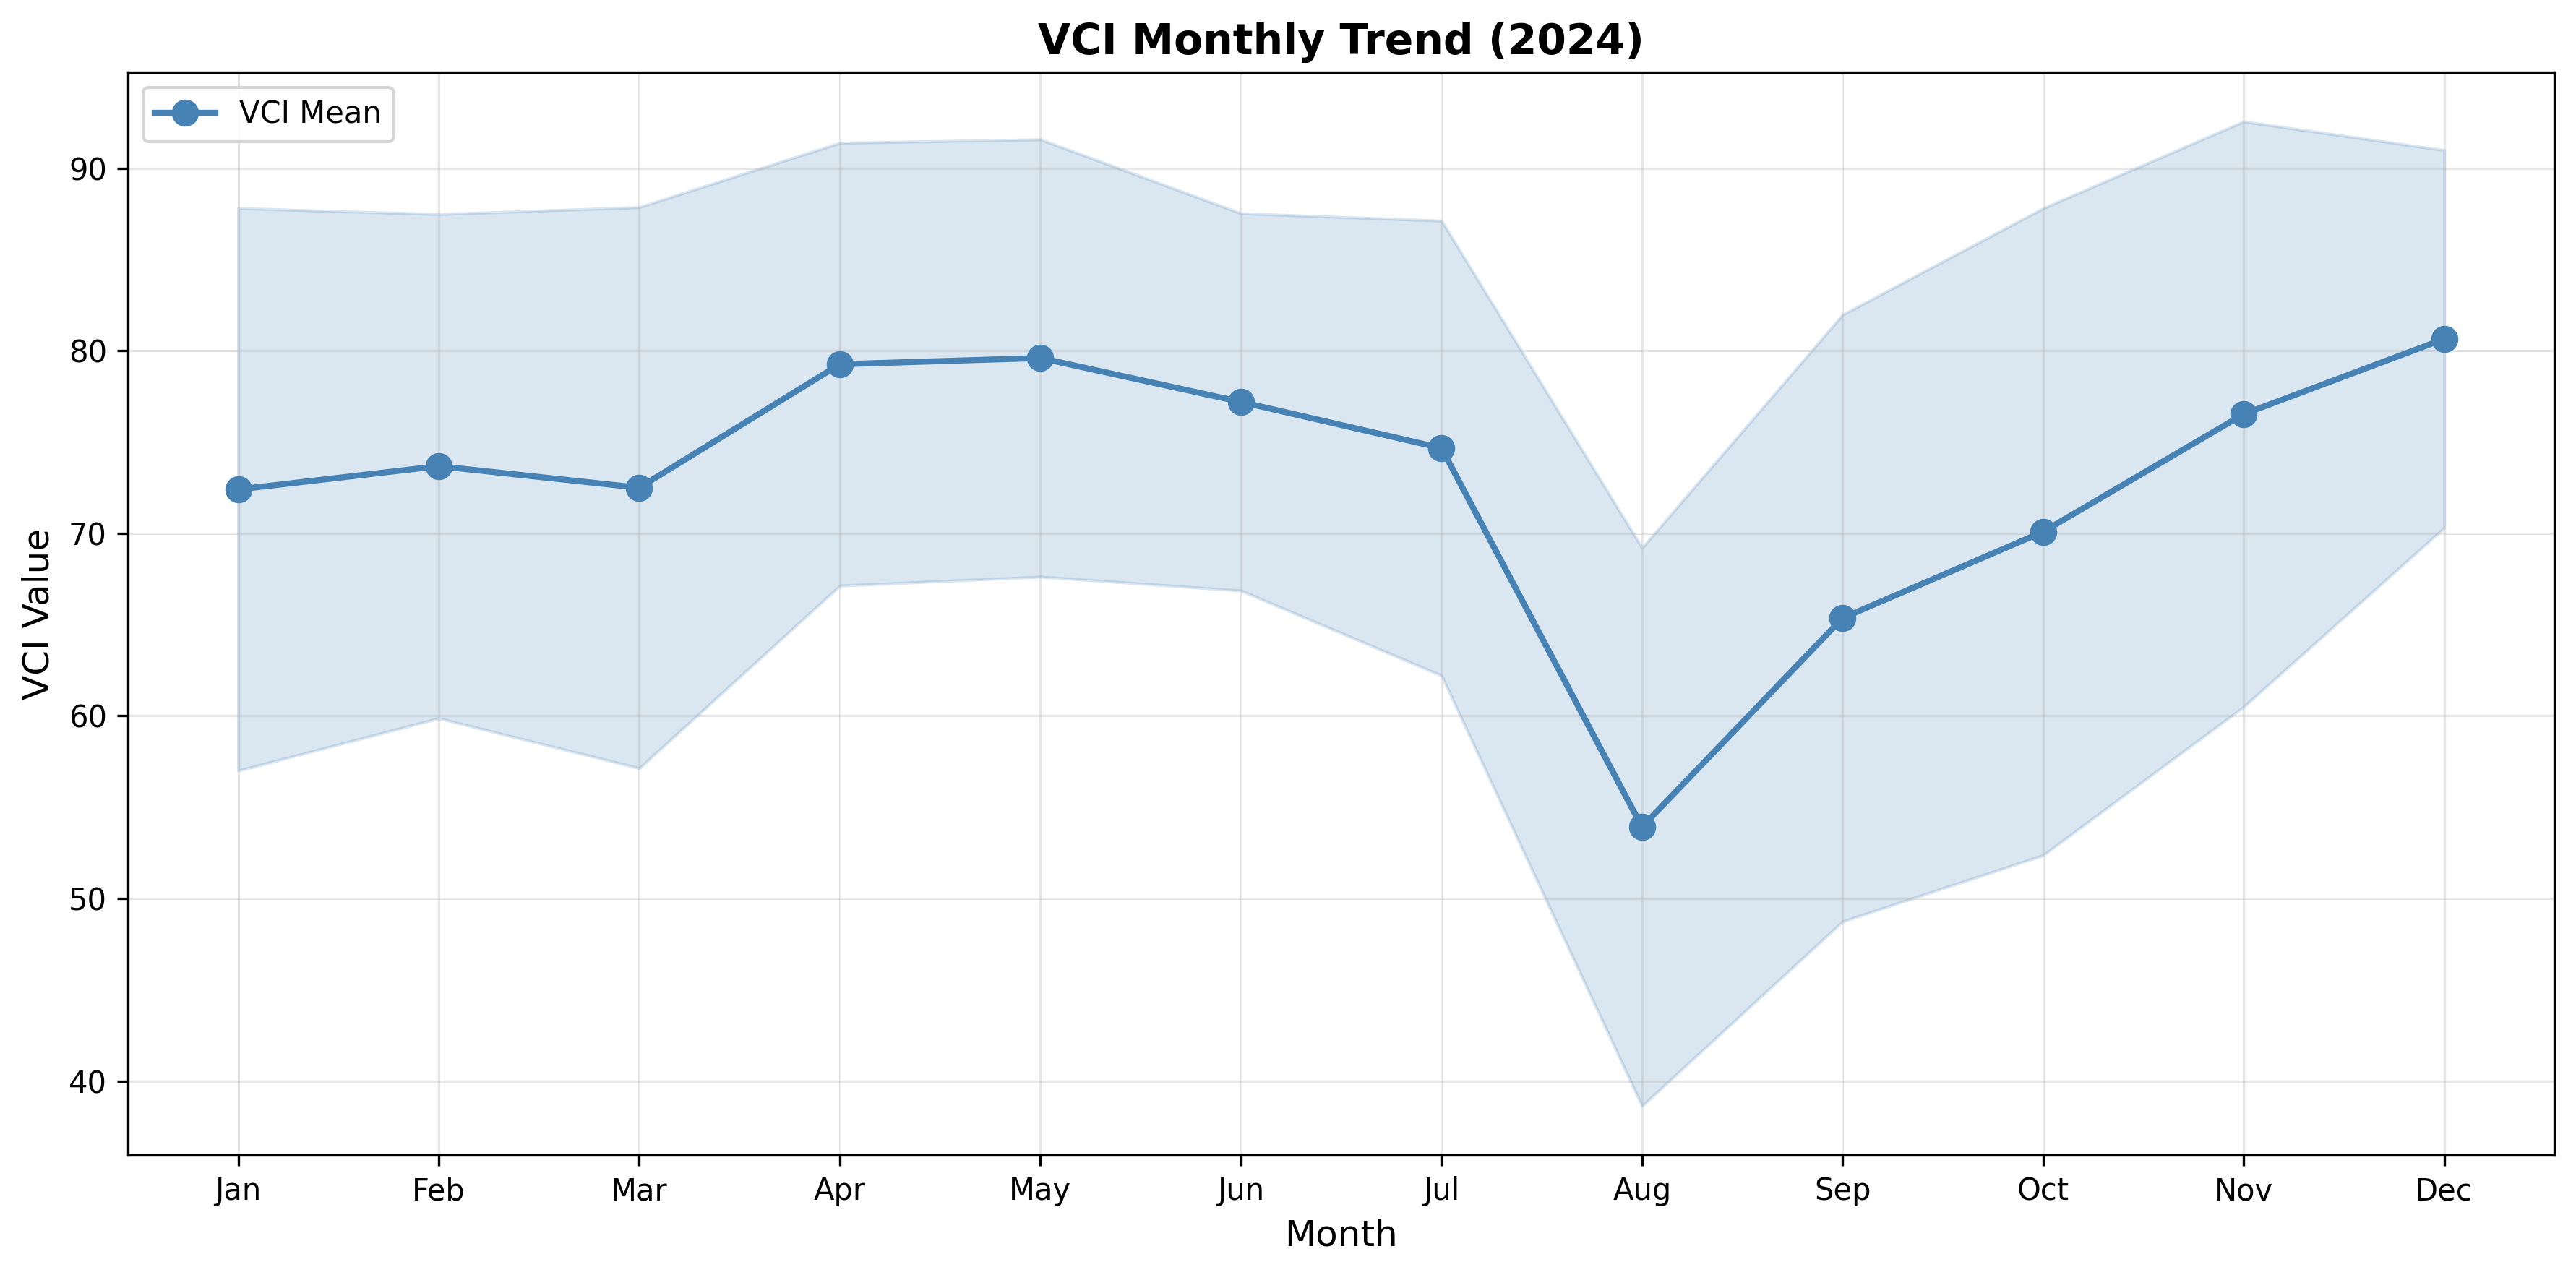

In [13]:
# Display trend plots
from IPython.display import Image, display
import os

trends_dir = analyzer.output_dir / "trends"

for index in config['indices']:
    img_path = trends_dir / f"{index}_trend_{year}.png"
    if img_path.exists():
        print(f"\n{index} Trend:")
        display(Image(filename=str(img_path)))

## 7. Generate Reports

In [14]:
# Generate markdown report
print("📝 Generating markdown report...")
md_path = generate_markdown_report(analyzer.output_dir, year)
print(f"✅ Markdown report: {md_path}")

# Generate PDF report (if reportlab is installed)
try:
    print("\n📘 Generating PDF report...")
    report_gen = ReportGenerator(analyzer.output_dir)
    pdf_path = report_gen.create_comprehensive_report(year)
    print(f"✅ PDF report: {pdf_path}")
except Exception as e:
    print(f"⚠️  PDF generation failed: {e}")
    print("   Install reportlab: pip install reportlab")

📝 Generating markdown report...
📝 Markdown report generated: modis_outputs/analysis_20260216_160637/MODIS_Report_2024.md
✅ Markdown report: modis_outputs/analysis_20260216_160637/MODIS_Report_2024.md

📘 Generating PDF report...
📘 Comprehensive PDF report generated: modis_outputs/analysis_20260216_160637/MODIS_Comprehensive_Report_2024.pdf
✅ PDF report: modis_outputs/analysis_20260216_160637/MODIS_Comprehensive_Report_2024.pdf


## 8. Analysis Summary

In [27]:
print("="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\n📅 Year: {year}")
print(f"📁 Output: {analyzer.output_dir}")
print(f"\n📊 Indices Analyzed: {', '.join(config['indices'])}")
print(f"\n📈 Outputs Generated:")
print(f"   ✅ Monthly composites")
print(f"   ✅ Trend plots")
print(f"   ✅ Statistical summaries")
print(f"   ✅ Reports")
print(f"\n🎉 Analysis successful!")
print("="*60)

ANALYSIS COMPLETE

📅 Year: 2024
📁 Output: modis_outputs/analysis_20260216_154125

📊 Indices Analyzed: NDVI, EVI, VCI

📈 Outputs Generated:
   ✅ Monthly composites
   ✅ Trend plots
   ✅ Statistical summaries
   ✅ Reports

🎉 Analysis successful!
